In [1]:
!pip install pandas

In [2]:
!pip install scipy

In [3]:
import pandas as pd
import sqlite3
from sqlite3 import Error
from pandas.plotting import scatter_matrix

In [4]:
def create_connection(path):
    connection = None
    try:
        connection = sqlite3.connect(path)
    except Error as e:
        print(f"The error {e} occured")
    return connection

connection = create_connection("../checking-logs.sqlite")

In [5]:
query = """
WITH diff AS (SELECT uid, AVG(strftime('%s', first_commit_ts) - deadlines) / 3600 AS avg_diff
FROM test LEFT JOIN deadlines ON labname = labs
WHERE labname <> 'project1'
GROUP BY uid),

views AS (SELECT pageviews.uid, COUNT(*) AS pageviews
                FROM pageviews
                GROUP BY pageviews.uid),
                
commits AS (SELECT checker.uid, COUNT(*) AS num_commits
                FROM checker
                WHERE labname <> 'project1'
                GROUP BY checker.uid)

SELECT diff.uid, avg_diff, pageviews, num_commits
FROM diff LEFT JOIN views ON views.uid = diff.uid
LEFT JOIN commits ON commits.uid = diff.uid
"""

df = pd.read_sql(query, connection)

df = df[["avg_diff", "pageviews", "num_commits"]].copy()

df

,avg_diff,pageviews,num_commits
0,-65.119778,28,62
1,-75.242444,89,20
2,-159.568796,143,61
3,-62.207667,47,51
4,-6.368148,3,5
5,-99.440417,16,118
6,-96.111181,10,65
7,-93.474944,179,79
8,-86.793833,149,60
9,-105.738222,317,18


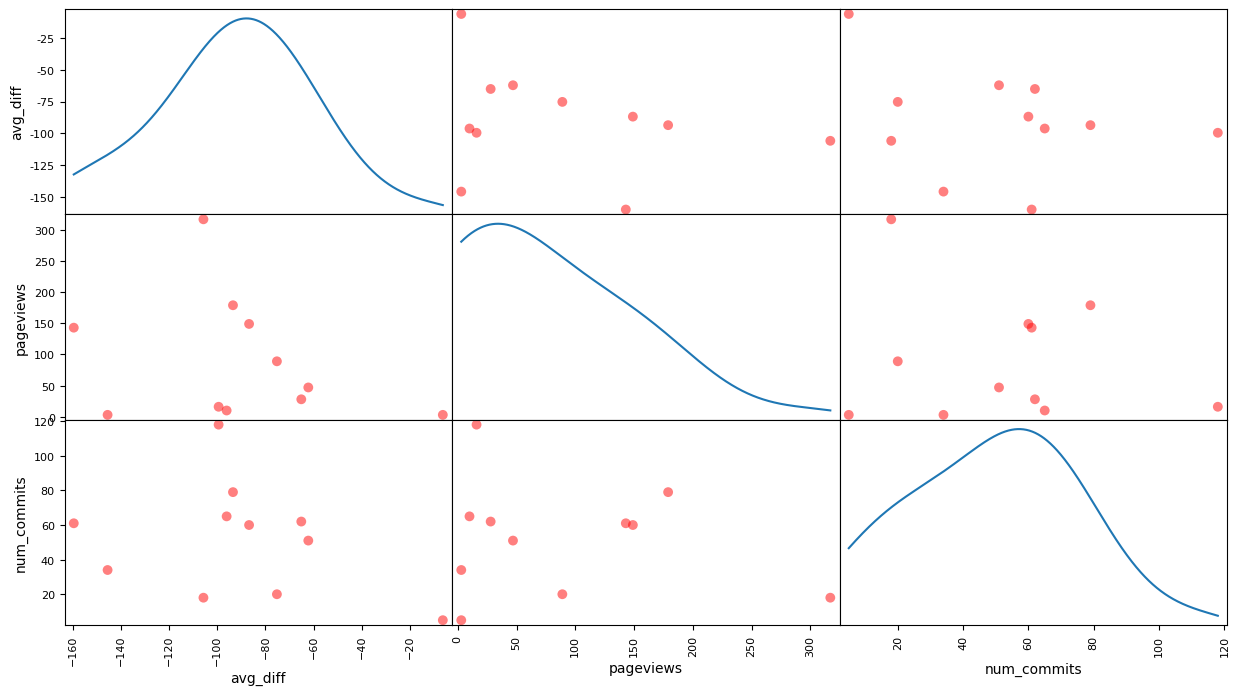

In [6]:
axes = scatter_matrix(df, diagonal="kde", figsize=(15,8), s=200, color="r")

In [7]:
connection.close()

* Можем ли мы сказать, что если у пользователя мало просмотров страниц, то у него, скорее всего, мало коммитов? Нет
* Можем ли мы сказать, что если у пользователя мало просмотров страниц, то у него, вероятно, есть небольшая средняя разница между первым фиксатом и крайним сроком лабораторного срока? Нет
* Можем ли мы сказать, что есть много пользователей с низким количеством коммитов и несколько с большим количеством коммитов? Да 
* Можем ли мы сказать, что есть много пользователей с небольшой средней разницей и несколько с большой средней разницей? Нет